In [46]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
from draw_graph import Scatter
from matplotlib.backends.backend_pdf import PdfPages

In [47]:
files_path = glob.glob('./FPT/20111*_relaxation_whole_lin22.6_70msec_100mW_5sec/whole_cells/*.csv')
files_path.sort()

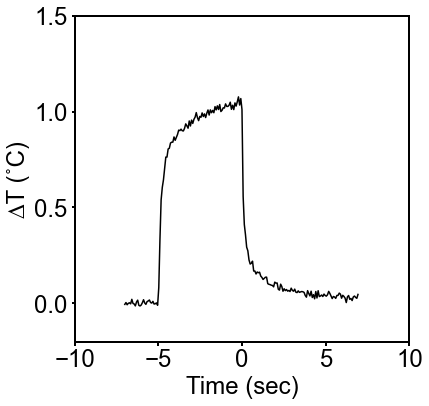

速い成分は0.103851sec
遅い成分は2.538170sec
割合は0.766123
時定数は2.250460


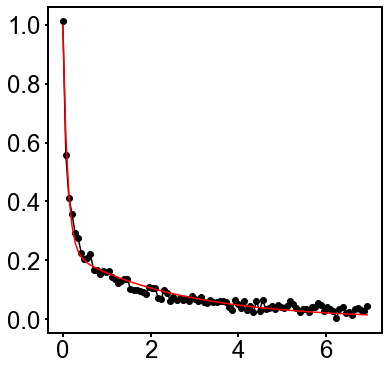

In [48]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_FPT = pd.DataFrame()

#データの平均化
average = np.zeros((1, 200))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+100])
    average += extract
    data_set_FPT = pd.concat([data_set_FPT, pd.DataFrame(extract)], axis = 1)
average_normal = average[0]/len(files_path)
average_normal = average_normal - np.mean(average_normal[:10])
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.xlim(-10, 10)
plt.ylim(-0.2, 1.5)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()


#温度緩和の時定数の計算
time = [(i)*0.07 for i in range(len(average_normal[100:]))]
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result = curve_fit(relaxation, time ,average_normal[100:])[0]
print('速い成分は%fsec' % result[1])
print('遅い成分は%fsec' % result[2])
print('割合は%f' % result[0])
time_constant = (result[0]*(result[1]**2) + (1-result[0])*(result[2]**2))/(result[0]*result[1] + (1-result[0])*(result[2]))
print('時定数は%f' % time_constant)

plt.figure(figsize = (6, 6))
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal[100:], color = 'Black', marker = 'o')
plt.plot(time, relaxation(np.ravel(time), result[0], result[1], result[2]), color = 'red')
plt.show()

In [49]:
file_path = glob.glob('./Cy3/2211??_cy3_Sa_3uM_26deg_100mW_5sec/csv/*.csv')
file_path.sort()
off_time = [140, 141, 131, 142, 141, 143, 138, 144, 139, 144, 130, 145, 140, 139, 135, 144, 140, 136, 133, 132, 137, 129, 133, 131, 144, 142, 141, 144, 141, 139, 140, 142, 141, 131, 144]

In [50]:
def figmake():
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['xtick.major.width'] = 1.0
    plt.rcParams['ytick.major.width'] = 1.0
    plt.rcParams['axes.linewidth'] = 1.0
    plt.rcParams["font.size"] = 20
    plt.figure(figsize = (6, 6))

<Figure size 432x432 with 0 Axes>

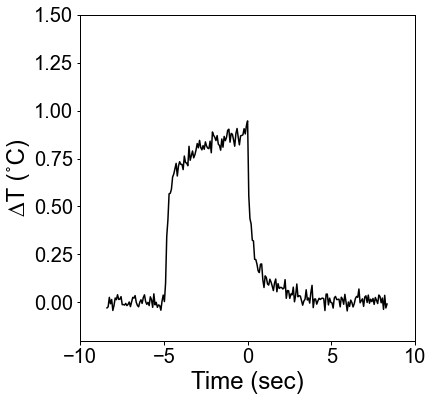

In [51]:
count = 0
ave_tmp_Cy3 = 0
data_set_Cy3 = pd.DataFrame()
plt.figure(figsize = (6, 6))

for path in file_path:
    decay = pd.DataFrame(np.array(pd.read_csv(path)[1:], dtype = 'float32'))[1]
    extract = decay[off_time[count] - 120 : off_time[count] + 120]
    coefficient = (np.mean(extract[-10:]) - np.mean(extract[:10]))/240
    extract = (extract - coefficient*range(len(extract))).iloc[:]
    extract = extract/extract.iloc[0]
    extract = extract.reset_index(drop = 'off')
    extract = -np.log(extract/np.mean(extract.iloc[:10]))/0.0306
    
    data_set_Cy3 = pd.concat([data_set_Cy3, extract], axis = 1)
    ave_tmp_Cy3 += extract
    count += 1

ave_tmp_Cy3 = ave_tmp_Cy3/len(file_path)
time = [(i-120)*0.07 for i in range(len(ave_tmp_Cy3))]
figmake()
plt.xlim(-10, 10)
plt.ylim(-0.2, 1.5)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.plot(time, ave_tmp_Cy3, color = 'black')
plt.show()

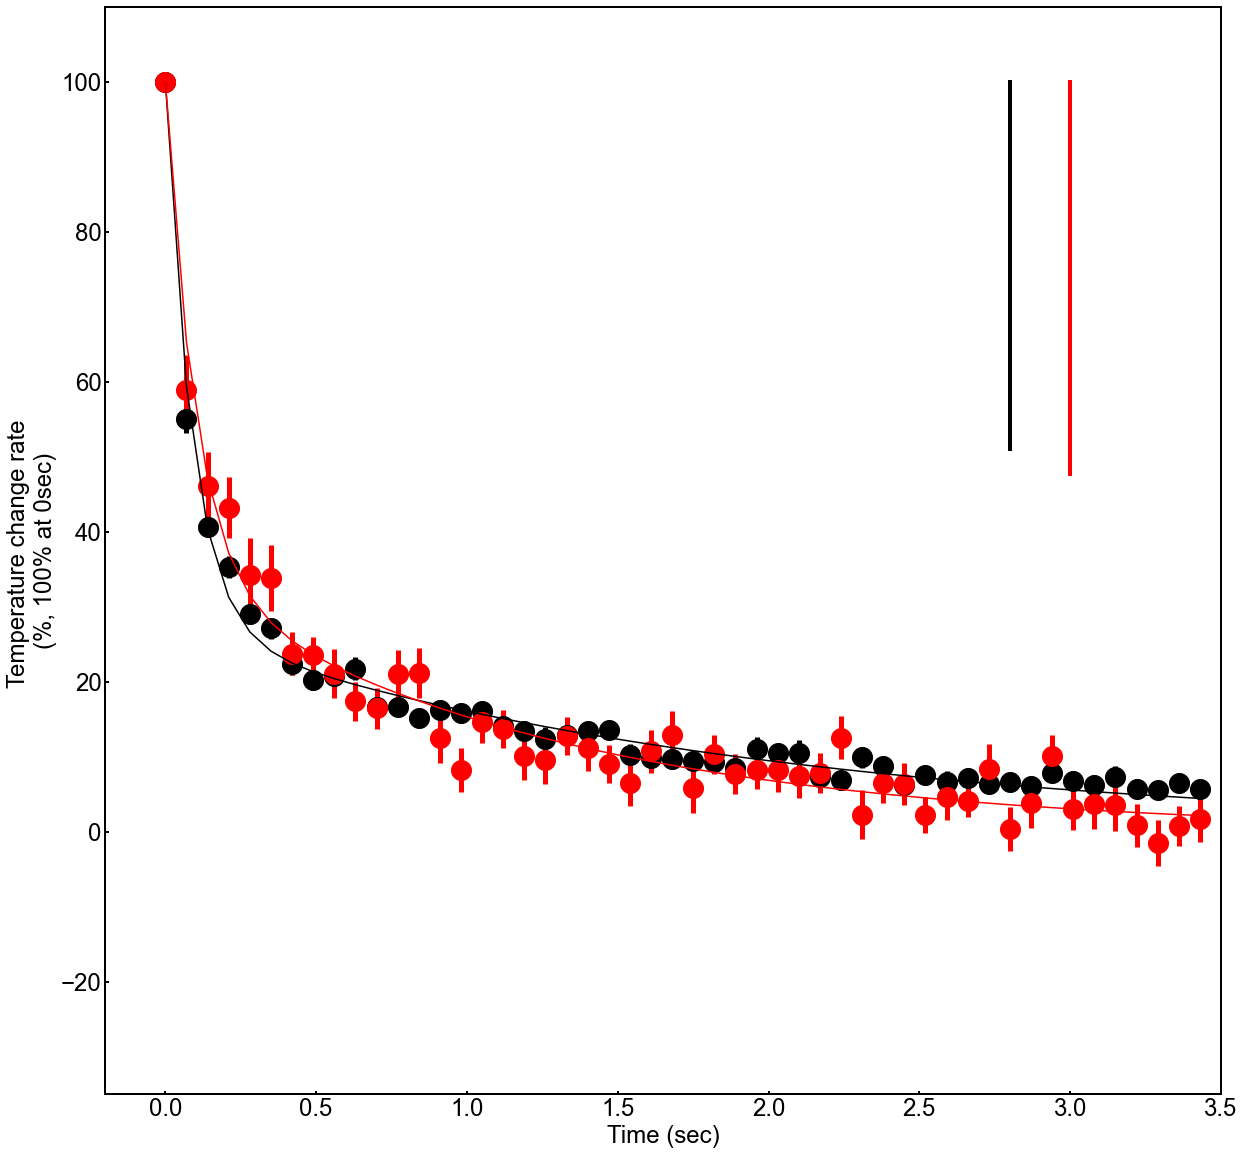

In [52]:
fig = plt.figure(figsize=(20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)


#1˚Cを示すバーを挿入(Cy3)
Cy3_bar = [100- 50/ave_tmp_Cy3[120]*i/100 for i in range(100)]
Cy3_bar_pos = [3.0 for i in range(len(Cy3_bar))]
plt.plot(Cy3_bar_pos, Cy3_bar, linewidth = 4, color = 'red', linestyle = '-')

#1˚Cを示すバーを挿入(FPT)
FPT_bar = [100- 50/average_normal[100]*i/100 for i in range(100)]
FPT_bar_pos = [2.8 for i in range(len(FPT_bar))]
plt.plot(FPT_bar_pos, FPT_bar, linewidth = 4, color = 'black', linestyle = '-')


#SEMの計算(Cy3)
data_set_Cy3 = data_set_Cy3/data_set_Cy3.iloc[120, :]*100
sem_Cy3 = data_set_Cy3.sem(axis = 1)

#SEMの計算(FPT)
data_set_FPT = data_set_FPT - np.mean(data_set_FPT.iloc[:10, :])
data_set_FPT = data_set_FPT/data_set_FPT.iloc[100, :]*100
sem_FPT = data_set_FPT.sem(axis = 1)


#plotting
time = [i*0.07 for i in range(len(data_set_Cy3[120:]))]
plt.errorbar(time[:50], average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_FPT)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time[:50], ave_tmp_Cy3[120:170]*100/ave_tmp_Cy3[120], yerr = np.ravel(sem_Cy3)[120:170], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time[:50], average_normal[100:150]*100/average_normal[100], color = 'Black', marker = 'o', markersize = 20, linewidth = 0)
plt.plot(time[:50], ave_tmp_Cy3[120:170]*100/ave_tmp_Cy3[120], color = 'red', markersize = 20, marker = 'o', linewidth = 0)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_FPT = curve_fit(relaxation, time[:50], average_normal[100:150]/average_normal[100])[0]
result_Cy3 = curve_fit(relaxation, time[:50], ave_tmp_Cy3[120:170]/ave_tmp_Cy3[120])[0]

#fitting結果の図示
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_FPT[0], result_FPT[1], result_FPT[2])*100, color = 'black')
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_Cy3[0], result_Cy3[1], result_Cy3[2])*100, color = 'red')



plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)


#pdfのセーブ
pp = PdfPages('./ralaxation_Cy3.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('normed_FPT.csv')
pd.DataFrame(ave_tmp_Cy3[120:170]*100/ave_tmp_Cy3[120]).to_csv('normed_Cy3.csv')
(sem_FPT)[100:150].to_csv('sem_FPT.csv')
(sem_Cy3)[120:170].to_csv('sem_Cy3.csv')

In [53]:
#welchのt検定
sum_FPT = data_set_FPT.iloc[102:150].sum().values
sum_Cy3 = data_set_Cy3.iloc[122:170].sum().values
sp.stats.ttest_ind(sum_FPT, sum_Cy3, equal_var = False)

Ttest_indResult(statistic=1.0641055594819468, pvalue=0.29295783438032913)

In [54]:
sem_FPT_bar = (sum_FPT*0.07).std(ddof = 1)/np.sqrt(len(sum_FPT))
sem_Cy3_bar = (sum_Cy3*0.07).std(ddof = 1)/np.sqrt(len(sum_Cy3))

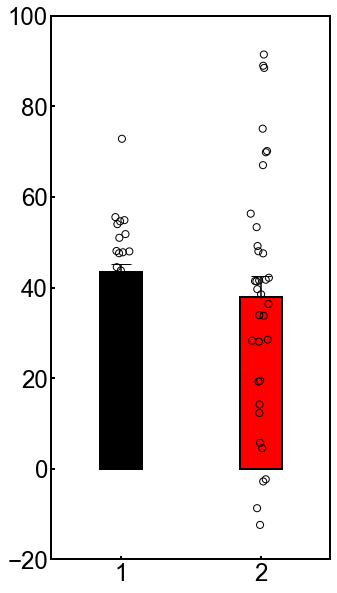

In [55]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_FPT_ave = np.average(sum_FPT*0.07)
sum_Cy3_ave = np.average(sum_Cy3*0.07)
plt.bar(1, sum_FPT_ave, yerr = [[0], [sem_FPT_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_FPT)) 
plt.scatter(x, sum_FPT*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(2, sum_Cy3_ave, yerr = [[0], [sem_Cy3_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_Cy3)) 
plt.scatter(x, sum_Cy3*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.ylim(-20, 100)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./AUC_Cy3.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_FPT*0.07).to_csv('AUC_FPT.csv')
pd.DataFrame(sum_Cy3*0.07).to_csv('AUC_Cy3.csv')

In [56]:
print(sum_FPT_ave)
print(sum_Cy3_ave)

43.32829
37.98412685987201


In [57]:
print(sem_FPT_bar)
print(sem_Cy3_bar)

1.9171741679965841
4.641876831883205
